# 5.6 高级操作  
上述介绍的操作函数大部分都是常有并且容易理解的，接下来我们将介绍部分常用，
但是稍复杂的功能函数。

## 1. tf.gather  
tf.gather 可以实现根据索引号收集数据的目的。

考虑班级成绩册的例子，假设共有 4个班级，每个班级 35 个学生，8 门科目，保存成绩册的张量 shape 为[4,35,8]

In [4]:
import tensorflow as tf

x = tf.random.uniform([4, 35, 8], maxval=100, dtype=tf.int32)
x.shape

TensorShape([4, 35, 8])

In [3]:
# 现在需要收集第 1~2 个班级的成绩册，可以给定需要收集班级的索引号：[0,1]，并指定班
# 级的维度 axis=0，通过 tf.gather 函数收集数据
tf.gather(x, [0, 1], axis=0).shape

TensorShape([2, 35, 8])

实际上，对于上述需求，通过切片𝑥[: 2]可以更加方便地实现。但是对于不规则的索引方
式，比如，需要抽查所有班级的第 1、4、9、12、13、27 号同学的成绩数据，则切片方式
实现起来非常麻烦，而 tf.gather 则是针对于此需求设计的，使用起来更加方便

In [6]:
tf.gather(x, [1, 4, 9, 12, 13, 27], axis=1).shape

TensorShape([4, 6, 8])

In [8]:
# 如果需要收集所有同学的第 3 和第 5 门科目的成绩
tf.gather(x, [2, 4], axis=2).shape

TensorShape([4, 35, 2])

**可以看到，tf.gather 非常适合索引号没有规则的场合，其中索引号可以乱序排列，此时收集的数据也是对应顺序**

In [11]:
a = tf.range(8)
a = tf.reshape(a, [4, 2])
tf.gather(a, [3, 1, 0, 2], axis=0)

<tf.Tensor: shape=(4, 2), dtype=int32, numpy=
array([[6, 7],
       [2, 3],
       [0, 1],
       [4, 5]], dtype=int32)>

In [12]:
# 我们将问题变得稍微复杂一点。如果希望抽查第[2,3]班级的第[3,4,6,27]号同学的科目
# 成绩，则可以通过组合多个 tf.gather 实现。[4, 35, 8]
tf.gather(tf.gather(x, [1, 2], axis=0), [2, 3, 5, 26], axis=1).shape

TensorShape([2, 4, 8])

这次我们希望抽查第 2 个班级的第 2 个同学的所有科
目，第 3 个班级的第 3 个同学的所有科目，第 4 个班级的第 4 个同学的所有科目。那么怎
么实现呢？

In [15]:
# 可以通过笨方式，一个一个的手动提取数据
x[1, 1].shape  # 收集第 2 个班级的第 2 个同学
x[2, 2].shape
x[3, 3].shape
tf.stack([x[1, 1], x[2, 2], x[3, 3]],axis=0).shape

TensorShape([3, 8])

这种方法也能正确地得到 shape 为[3,8]的结果，其中 3 表示采样点的个数，4 表示每个采样
点的数据，看上去似乎也不错。但是它最大的问题在于手动串行方式地执行采样，计算效
率极低。有没有更好的方式实现呢？
这就是下一节要介绍的 tf.gather_nd 的功能。

## 2. tf.gather_nd  


通过tf.gather_nd 函数，可以通过指定每次采样点的多维坐标来实现采样多个点的目的。回到上面的挑战，我们希望抽查第2个班级的第2个同学的所有科目，第3个班级的第3个同学的所有科目，第4个班级的第4个同学的所有科目。那么这3个采样点的索引坐标可以记为：［1,1］、［2,2］、［3,3］，我们将这个采样方案合并为一个 List 参数，即［［1,1］，［2,2］，［3,3］］，通过tf.gather_nd 函数即可，实现如下：

In [ ]:
# 根据多维坐标收集数据
tf.gather_nd(x, [[1, 1], [2, 2], [3, 3]]).shape

TensorShape([3, 8])

一般地，在使用 tf.gather_nd 采样多个样本时，例如希望采样𝑖号班级，𝑗个学生，𝑘门
科目的成绩，则可以表达为[. . . ,[𝑖,𝑗, 𝑘], . . .]，**外层的括号长度为采样样本的个数，内层列表包含了每个采样点的索引坐标**

## 3. tf.boolean_mask  
除了可以通过给定索引号的方式采样，还可以通过给定掩码(Mask)的方式进行采样。

继续以 shape 为[4,35,8]的成绩册张量为例，这次我们以掩码方式进行数据提取，考虑在班级维度上进行采样，对这 4 个班级的采样方案的掩码为
mask = [True, False, False, True]
即采样第 1 和第 4 个班级的数据，通过 tf.boolean_mask(x, mask, axis)可以在 axis 轴上根据
mask 方案进行采样，实现为：


In [18]:
tf.boolean_mask(x, [True, False, False, True], axis=0).shape

TensorShape([2, 35, 8])

现在我们来考虑与 tf.gather_nd 类似方式的多维掩码采样方式。为了方便演示，我们将
班级数量减少到
[2,3,8]。如果希望采样第
2 个，学生的数量减少到
1 个班级的第 1~2
3
号学生，第
个，即一个班级只有
2 个班级的第
3 个学生，
2~3 号学生，通过
shape 为
tf.gather_nd 可以实现为：

In [19]:
x = tf.random.uniform([2, 3, 8], maxval=100, dtype=tf.int32)
tf.gather_nd(x,[[0,0],[0,1],[1,1],[1,2]]) # 多维坐标采集

<tf.Tensor: shape=(4, 8), dtype=int32, numpy=
array([[51, 42, 33, 44, 72, 47, 93, 77],
       [92, 98, 76, 89, 89, 77, 93, 55],
       [96,  4, 39, 70, 39,  3, 80, 62],
       [88, 20, 39, 56,  9, 40, 42, 31]], dtype=int32)>

In [20]:
# 多维掩码采样
tf.boolean_mask(x,[[True,True,False],[False,True,True]])

<tf.Tensor: shape=(4, 8), dtype=int32, numpy=
array([[51, 42, 33, 44, 72, 47, 93, 77],
       [92, 98, 76, 89, 89, 77, 93, 55],
       [96,  4, 39, 70, 39,  3, 80, 62],
       [88, 20, 39, 56,  9, 40, 42, 31]], dtype=int32)>

## 4. tf.where

通过 tf.where(cond, a, b)操作可以根据 cond 条件的真假从参数A或B中读取数据，条件判定规则如下：
$$
o_i = \begin{cases}
a_i & \text{cond}_i \text{为 True} \\
b_i & \text{cond}_i \text{为 False}
\end{cases}
$$
其中i为张量的元素索引，返回的张量大小与A和B一致，当对应位置的condᵢ为 True，oᵢ从aᵢ中复制数据；当对应位置的condᵢ为 False，oᵢ从bᵢ中复制数据。考虑从2个全1和全0的3×3大小的张量A和B中提取数据，其中condᵢ为 True 的位置从A中对应位置提取元素1，condᵢ为 False 的位置从B对应位置提取元素0，代码如下：

In [ ]:
a = tf.ones([3, 3])  # 构造 a 为全 1 矩阵
b = tf.zeros([3, 3])  # 构造 b 为全 0 矩阵
# 构造采样条件
cond = tf.constant(
    [[True, False, False], [False, True, False], [True, True, False]])
tf.where(cond, a, b)  # 根据条件从 a,b 中采样

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[1., 0., 0.],
       [0., 1., 0.],
       [1., 1., 0.]], dtype=float32)>

可以看到，返回的张量中为 1 的位置全部来自张量 a，返回的张量中为 0 的位置来自张量b。  
当参数 a=b=None 时，即 a 和 b 参数不指定，**tf.where 会返回 cond 张量中所有 True 的元素的索引坐标**。考虑如下 cond 张量

In [25]:
# 构造的 cond 张量
cond

<tf.Tensor: shape=(3, 3), dtype=bool, numpy=
array([[ True, False, False],
       [False,  True, False],
       [ True,  True, False]])>

其中 True 共出现 4 次，每个 True 元素位置处的索引分别为[0,0]、[1,1]、[2,0]、[2,1]，可
以直接通过 tf.where(cond)形式来获得这些元素的索引坐标，代码如下

In [ ]:
tf.where(cond)

<tf.Tensor: shape=(4, 2), dtype=int64, numpy=
array([[0, 0],
       [1, 1],
       [2, 0],
       [2, 1]])>

那么这有什么用途呢？考虑一个场景，我们需要提取张量中所有正数的数据和索引。
首先构造张量 a，并通过比较运算得到所有正数的位置掩码

In [26]:
x = tf.random.normal([3, 3])  # 构造 a
# 通过比较运算，得到所有正数的掩码
mask = x > 0
mask

<tf.Tensor: shape=(3, 3), dtype=bool, numpy=
array([[ True, False,  True],
       [ True,  True, False],
       [ True, False, False]])>

In [29]:
# 通过 tf.where 提取此掩码处 True 元素的索引坐标
indices = tf.where(mask)
indices

<tf.Tensor: shape=(5, 2), dtype=int64, numpy=
array([[0, 0],
       [0, 2],
       [1, 0],
       [1, 1],
       [2, 0]])>

In [31]:
# 拿到索引后，通过 tf.gather_nd 即可恢复出所有正数的元素
tf.gather_nd(x, indices)

<tf.Tensor: shape=(5,), dtype=float32, numpy=
array([0.378799  , 1.1345602 , 0.28268212, 0.44426718, 0.6419776 ],
      dtype=float32)>

In [32]:
# 当我们得到掩码 mask 之后，也可以直接通过 tf.boolean_mask 获取所有正数的元素向量
tf.boolean_mask(x, mask)

<tf.Tensor: shape=(5,), dtype=float32, numpy=
array([0.378799  , 1.1345602 , 0.28268212, 0.44426718, 0.6419776 ],
      dtype=float32)>

通过上述一系列的比较、索引号收集和掩码收集的操作组合，我们能够比较直观地感
受到这个功能是有很大的实际应用的，并且深刻地理解它们的本质有利于更加灵活地选用
简便高效的方式实现我们的目的

## 5. scatter_nd

通过 **tf.scatter_nd(indices, updates, shape)**函数可以高效地刷新张量的部分数据，但是这
个函数只能在全 0 的白板张量上面执行刷新操作，因此可能需要结合其它操作来实现现有
张量的数据刷新功能。
如下图 5.3 所示，演示了一维张量白板的刷新运算原理。白板的形状通过 shape 参数
表示，需要刷新的数据索引号通过 indices 表示，新数据为 updates。根据 indices 给出的索
引位置将 updates 中新的数据依次写入白板中，并返回更新后的结果张量

In [33]:
# 构造需要刷新数据的位置参数，即为 4、3、1 和 7 号位置
indices = tf.constant([[4], [3], [1], [7]])
# 构造需要写入的数据，4 号位写入 4.4,3 号位写入 3.3，以此类推
updates = tf.constant([4.4, 3.3, 1.1, 7.7])
# 在长度为 8 的全 0 向量上根据 indices 写入 updates 数据
tf.scatter_nd(indices, updates, [8])

<tf.Tensor: shape=(8,), dtype=float32, numpy=array([0. , 1.1, 0. , 3.3, 4.4, 0. , 0. , 7.7], dtype=float32)>

考虑 3 维张量的刷新例子，如下图 5.4 所示，白板张量的 shape 为[4,4,4]，共有 4 个通
道的特征图，每个通道大小为4 × 4，现有 2 个通道的新数据 updates:[2,4,4]，需要写入索
引为[1,3]的通道上。

In [35]:
indices = tf.constant([[1], [3]])
updates = tf.constant([  # 构造写入数据，即 2 个矩阵
    [[5, 5, 5, 5], [6, 6, 6, 6], [7, 7, 7, 7], [8, 8, 8, 8]],
    [[1, 1, 1, 1], [2, 2, 2, 2], [3, 3, 3, 3], [4, 4, 4, 4]]
])
# 在 shape 为[4,4,4]白板上根据 indices 写入 updates
tf.scatter_nd(indices, updates, [4, 4, 4])

<tf.Tensor: shape=(4, 4, 4), dtype=int32, numpy=
array([[[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[5, 5, 5, 5],
        [6, 6, 6, 6],
        [7, 7, 7, 7],
        [8, 8, 8, 8]],

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[1, 1, 1, 1],
        [2, 2, 2, 2],
        [3, 3, 3, 3],
        [4, 4, 4, 4]]], dtype=int32)>

## 6.meshgrid

通过 tf.meshgrid 函数可以方便地生成二维网格的采样点坐标，方便可视化等应用场景。考虑 2 个自变量 x 和 y 的 Sinc 函数表达式为
$$
z = \frac{\sin(x^2 + y^2)}{x^2 + y^2}
$$
如果需要绘制在 x∈[−8,8],y∈[−8,8] 区间的 Sinc 函数的 3D 曲面，如图 5.5 所示，则首先需要生成 x 和 y 轴的网格点坐标集合 {(x,y)} ，这样才能通过 Sinc 函数的表达式计算函数在每个 (x,y) 位置的输出值 z。可以通过如下方式生成 1 万个坐标采样点：

In [50]:
points = []


def sinc(x, y):
    z = tf.sqrt(x**2+y**2)
    z = tf.sin(z)/z  # sinc 函数实现
    return z


# for x in range(-8, 8, 100):
#     for y in range(-8, 8, 100):
#         z = sinc(x, y)
#         points.append([x, y, z])

很明显这种串行采样方式效率极低，那么有没有简洁高效地方式生成网格坐标呢？答案是
肯定的，tf.meshgrid 函数即可实现。

In [56]:
x = tf.linspace(-8., 8, 100)
y = tf.linspace(-8., 8, 100)
x, y = tf.meshgrid(x, y)  # 生成网格点，并内部拆分后返回
z = sinc(x, y)
x.shape, y.shape  # 打印拆分后的所有点的 x,y 坐标张量 shape

(TensorShape([100, 100]), TensorShape([100, 100]))

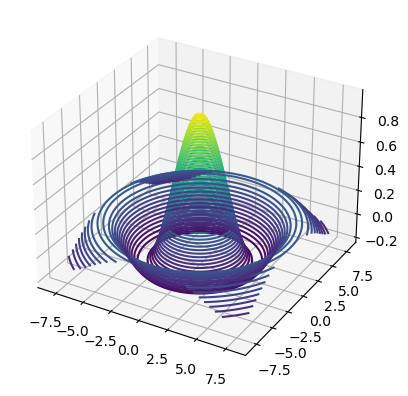

In [55]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(projection='3d')  # ✅ 正确方式创建 3D axes
ax.contour3D(x.numpy(), y.numpy(), z.numpy(), 50)
plt.show()